In [1]:
import os
from dotenv import load_dotenv
import oracledb
import pandas as pd

load_dotenv()
USER = os.getenv("ORACLE_USER")
PASSWORD = os.getenv("ORACLE_PASSWORD")
DSN = os.getenv("ORACLE_DSN")

with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    df=pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)
# with문 블록을 벗어나는 순간 자동으로 conn.close()가 호출되어 안정적임

print("연결 및 쿼리 성공! 데이터 shape:", df.shape)
df.head()

연결 및 쿼리 성공! 데이터 shape: (37, 7)


C:\Users\Nopen\AppData\Local\Temp\ipykernel_18796\1881069285.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


,ORDER_ID,MENU_NAME,CATEGORY,PRICE,RATING,REGION,ORDER_DATE
0,35,짬뽕,중식,9500,4.3,송파구,2026-08-21
1,36,우동,일식,8500,4.1,강남구,2026-08-22
2,37,김밥,분식,5500,4.2,서초구,2026-08-22
3,1,떡볶이,분식,9000,4.5,강남구,2026-08-01
4,2,치킨,치킨,22000,4.8,서초구,2026-08-02


In [2]:
# [셀 1] 한글 폰트 및 마이너스 기호 설정
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

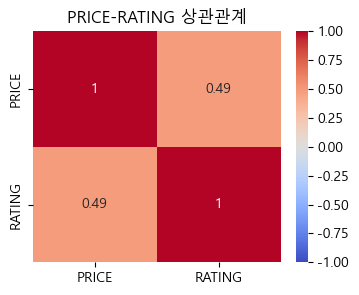

In [3]:
# 숫자 컬럼2개
basic_corr = df[["PRICE", "RATING"]].corr()

plt.figure(figsize=(4, 3))
sns.heatmap(basic_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("PRICE-RATING 상관관계")
plt.show()

In [4]:
# 카테고리를 숫자로 바꿔서(원-핫 인코딩) 상관관계 살펴보기
# 예) 주문이 치킨이면 1, 아니면 0
# CATEGORY를 0/1 더미 변수로 변환
category_dummies = pd.get_dummies(df["CATEGORY"], prefix="CAT")
print("=== 원-핫 인코딩 결과 (앞 5행) ===")
print(category_dummies.head())

# 원본 숫자 컬럼(PRICE, RATING)과 더미 컬럼을 옆으로 이어붙임
extended_df = pd.concat([df[["PRICE", "RATING"]], category_dummies], axis=1)
extended_corr = extended_df.corr()
print(extended_df)

print("\n=== 확장된 상관관계 행렬 shape ===")
print(extended_corr.shape)

=== 원-핫 인코딩 결과 (앞 5행) ===
   CAT_분식  CAT_일식  CAT_중식  CAT_치킨  CAT_피자
0   False   False    True   False   False
1   False    True   False   False   False
2    True   False   False   False   False
3    True   False   False   False   False
4   False   False   False    True   False
    PRICE  RATING  CAT_분식  CAT_일식  CAT_중식  CAT_치킨  CAT_피자
0    9500     4.3   False   False    True   False   False
1    8500     4.1   False    True   False   False   False
2    5500     4.2    True   False   False   False   False
3    9000     4.5    True   False   False   False   False
4   22000     4.8   False   False   False    True   False
5   25000     4.2   False   False   False   False    True
6    8000     4.0   False   False    True   False   False
7   13000     4.6   False   False    True   False   False
8   11000     4.3   False    True   False   False   False
9   18000     4.4   False   False    True   False   False
10   8500     4.3    True   False   False   False   False
11   7000     4.1    True 

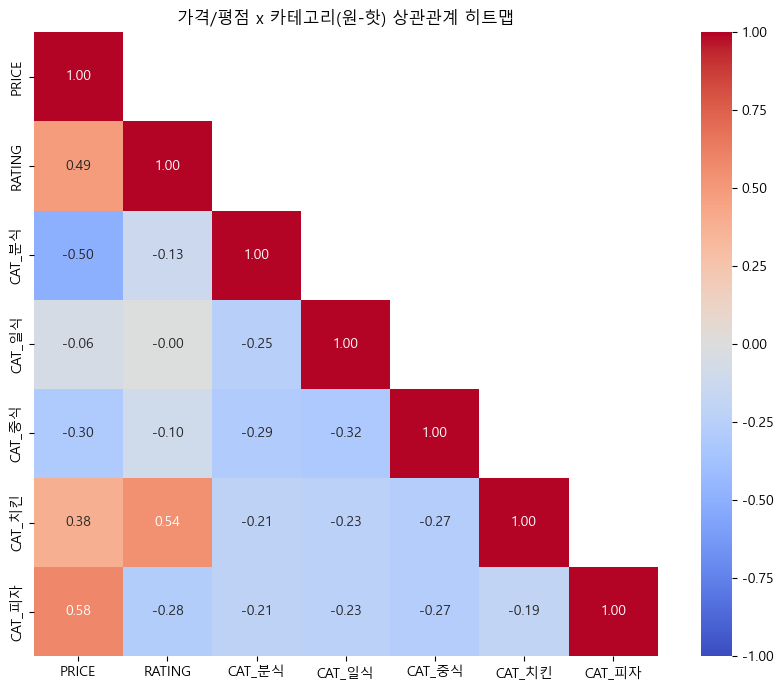

In [5]:
import numpy as np

# mask로 대각선 위쪽(중복되는 절반)을 가려서 아래쪽 절반만 보이게 처리
# np.triu:triangle upper -> 위쪽 삼각형만 남기고 나머지는 지움
mask = np.triu(np.ones_like(extended_corr, dtype=bool),k=1) # 모두 True

plt.figure(figsize=(9, 7))
sns.heatmap(
    extended_corr,
    mask=mask,              # 위쪽 절반 숨기기 (대칭이라 중복이므로)
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
)
plt.title("가격/평점 x 카테고리(원-핫) 상관관계 히트맵")
plt.tight_layout()
plt.show()

In [6]:
# 요일 x 카테고리 - 주문 패턴 피벗 히트맵
# ORDER_DATE에서 **요일**을 뽑아내어 "무슨 요일에 어떤 메뉴가 잘 팔리는지" 패턴

# 요일 컬럼 추가 (영어 요일명을 한글로 매핑)
weekday_map = {
    "Monday": "월", "Tuesday": "화", "Wednesday": "수", "Thursday": "목",
    "Friday": "금", "Saturday": "토", "Sunday": "일",
}

df["요일"] = df["ORDER_DATE"].dt.day_name().map(weekday_map)
df.head()

weekday_order = ['월','화','수','목','금','토','일']
df['요일'] = pd.Categorical(df['요일'], categories=weekday_order, ordered=True)
df.head()

,ORDER_ID,MENU_NAME,CATEGORY,PRICE,RATING,REGION,ORDER_DATE,요일
0,35,짬뽕,중식,9500,4.3,송파구,2026-08-21,금
1,36,우동,일식,8500,4.1,강남구,2026-08-22,토
2,37,김밥,분식,5500,4.2,서초구,2026-08-22,토
3,1,떡볶이,분식,9000,4.5,강남구,2026-08-01,토
4,2,치킨,치킨,22000,4.8,서초구,2026-08-02,일


In [7]:
# 원래로 하면 (가나다라.. 순서) -> 금 목 수 월 일 토 화
weekday_order = ["월", "화", "수", "목", "금", "토", "일"]
df["요일"] = pd.Categorical(df["요일"], categories=weekday_order, ordered=True)

# 요일 x 카테고리별 주문 건수 피벗
weekday_category_pivot = pd.pivot_table(
    df, index="요일", columns="CATEGORY", values="ORDER_ID",
    aggfunc="count", fill_value=0, observed=False,
)
print(weekday_category_pivot)

CATEGORY  분식  일식  중식  치킨  피자
요일                          
월          0   0   0   2   3
화          0   1   2   0   2
수          0   1   4   0   0
목          1   1   2   1   0
금          0   2   2   0   1
토          4   3   0   0   0
일          2   0   0   3   0


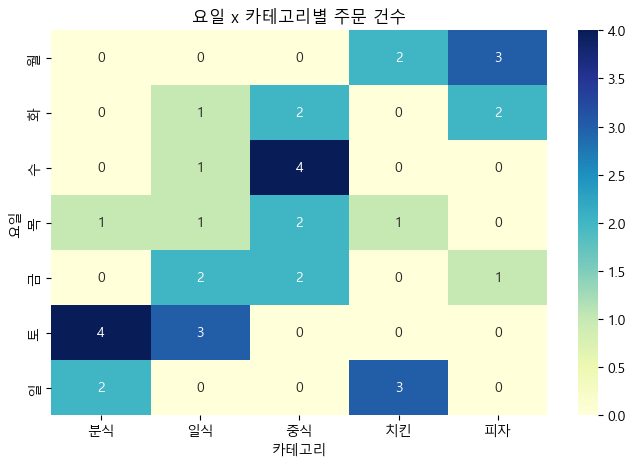

In [8]:
plt.figure(figsize=(8, 5))
sns.heatmap(weekday_category_pivot, annot=True, fmt="d", cmap="YlGnBu")
plt.title("요일 x 카테고리별 주문 건수")
plt.ylabel("요일")
plt.xlabel("카테고리")
plt.show()

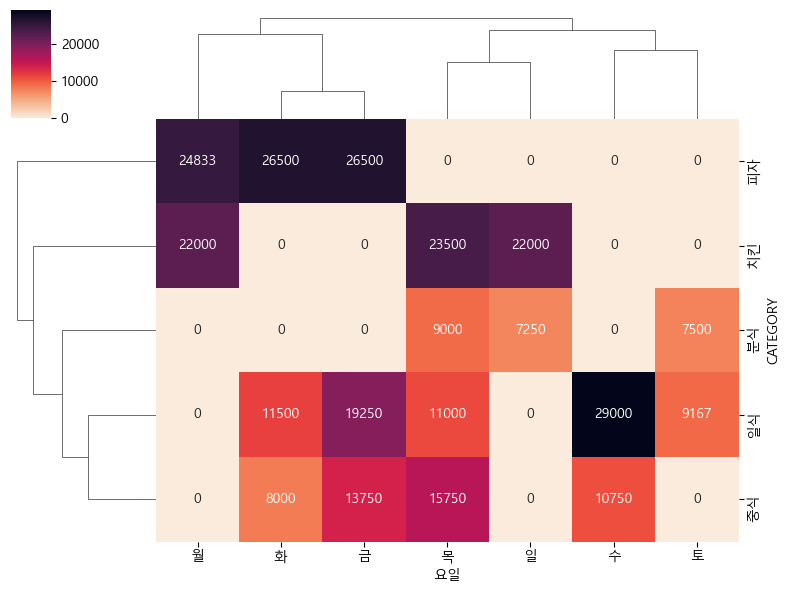

In [9]:
## clustermap - 비슷한 카테고리끼리 자동으로 묶어보기
"""
`clustermap`은 일반 히트맵과 달리, **행/열의 순서를 데이터가 비슷한 것끼리 자동으로 재배치**
"비슷하게 움직이는 애들끼리 자동으로 옆자리에 앉혀주는 것"이라고 생각
필수 개념은 아니지만, 데이터가 많아질 때 히트맵만으로는 안 보이던 그룹 구조를 발견하는 데 유용
"""
# uv pip install scipy
# 카테고리별 x 요일별 평균 가격으로 clustermap 그려보기
weekday_price_pivot = pd.pivot_table(
    df, index="CATEGORY", columns="요일", values="PRICE",
    aggfunc="mean", fill_value=0, observed=False,
)

sns.clustermap(weekday_price_pivot, annot=True, fmt=".0f", cmap="rocket_r", figsize=(8, 6))
plt.show()